## input file 
### check for null
### check for preprocessing 
### standardize
### model

In [65]:
import ipp

In [66]:

model_Eval = ipp.pd.DataFrame()
ipp.warnings.filterwarnings("ignore")
ipp.initial_Check()

In [67]:
df = ipp.pd.read_csv('/Users/nikhilprao/Documents/Data/Boston.csv', index_col=0)
df.reset_index(drop=True)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,6.48,22.0


## ask user for file 
### for now its commented 

In [68]:
# import tkinter as tk
# from tkinter import filedialog

# # Initialize tkinter window
# root = tk.Tk()
# root.withdraw()  # Hide the root window

# # Ask the user to upload any file
# file_path = filedialog.askopenfilename(title="Select a file")

# # Send the uploaded file to the function
# if file_path:
#     df = ipp.load_data(file_path)
#     print("Dataset loaded successfully!")
# else:
#     print("No file selected.")


## Pre processing unit will come here

In [69]:
df.isnull().sum()
# applying the method
nan_in_df = df.isnull().sum().any()
 
# Print the dataframe
print(type(nan_in_df))

df.info()

df.describe()

<class 'numpy.bool_'>
<class 'pandas.core.frame.DataFrame'>
Index: 506 entries, 1 to 506
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  lstat    506 non-null    float64
 12  medv     506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 55.3 KB


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


### Ask User for predictive column

In [70]:
# Display column names to the user
print("Available predictor variables:")
for idx, col in enumerate(df.columns):
    print(f"{idx + 1}. {col}")

# Ask the user to choose a predictor variable
selected_index = int(input("Enter the index of the predictor variable you want to choose: ")) - 1

# Validate user input
if 0 <= selected_index < len(df.columns):
    pattern = df.columns[selected_index]
    print(f"Selected predictor variable: {pattern}")
else:
    print("Invalid index selected. Please choose a valid index.")


predictor_variable = df.filter(regex=f'^{pattern}').columns[0]

Available predictor variables:
1. crim
2. zn
3. indus
4. chas
5. nox
6. rm
7. age
8. dis
9. rad
10. tax
11. ptratio
12. lstat
13. medv
Selected predictor variable: medv


## Model starts here

In [71]:
ipp.interModel(df, predictor_variable, "raw")

## Pipeline for Outliers

## Need to check on this issue but later

In [72]:
df_outlier_cleaned = ipp.main_outliers(df, predictor_variable)

IQR method removes: 40 outliers
SD3 method removes: 0 outliers
Percentile method removes: 6 outliers
Method: iqr, Outliers removed: 40
Method: sd3, Outliers removed: 0
Method: percentile, Outliers removed: 6

Best method used: iqr
Number of outliers removed: 40


In [73]:
df_outlier_cleaned

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
502,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,9.67,22.4
503,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,9.08,20.6
504,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,5.64,23.9
505,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,6.48,22.0


In [74]:
ipp.interModel(df_outlier_cleaned, predictor_variable, "outliers_removed_iqr")
# ipp.Comp_plot_boxplots(df, df_outlier_cleaned, predictor_variable)

In [75]:
# fig, axs = ipp.plt.subplots(ncols=7, nrows=2, figsize=(20, 10))
# index = 0
# axs = axs.flatten()
# for col, value in df_outlier_cleaned.items() :
#     ipp.sns.distplot(value, ax=axs[index])
#     index += 1
# ipp.plt. tight_layout (pad=0.5, w_pad=0.7, h_pad=5.0)

In [76]:
# #box plot to all features to show outliers
# fig, axs = ipp.plt.subplots(ncols=7, nrows=2, figsize=(20, 10))
# index = 0
# axs = axs.flatten()
# for col, value in df_outlier_cleaned.items():
#     ipp.sns.boxplot(y=col, data=df_outlier_cleaned, ax=axs[index])
#     index += 1
# ipp.plt.tight_layout (pad=0.5, w_pad=0.7, h_pad=5.0)

In [77]:
# ipp.plot_numerical_columns(df_outlier_cleaned)

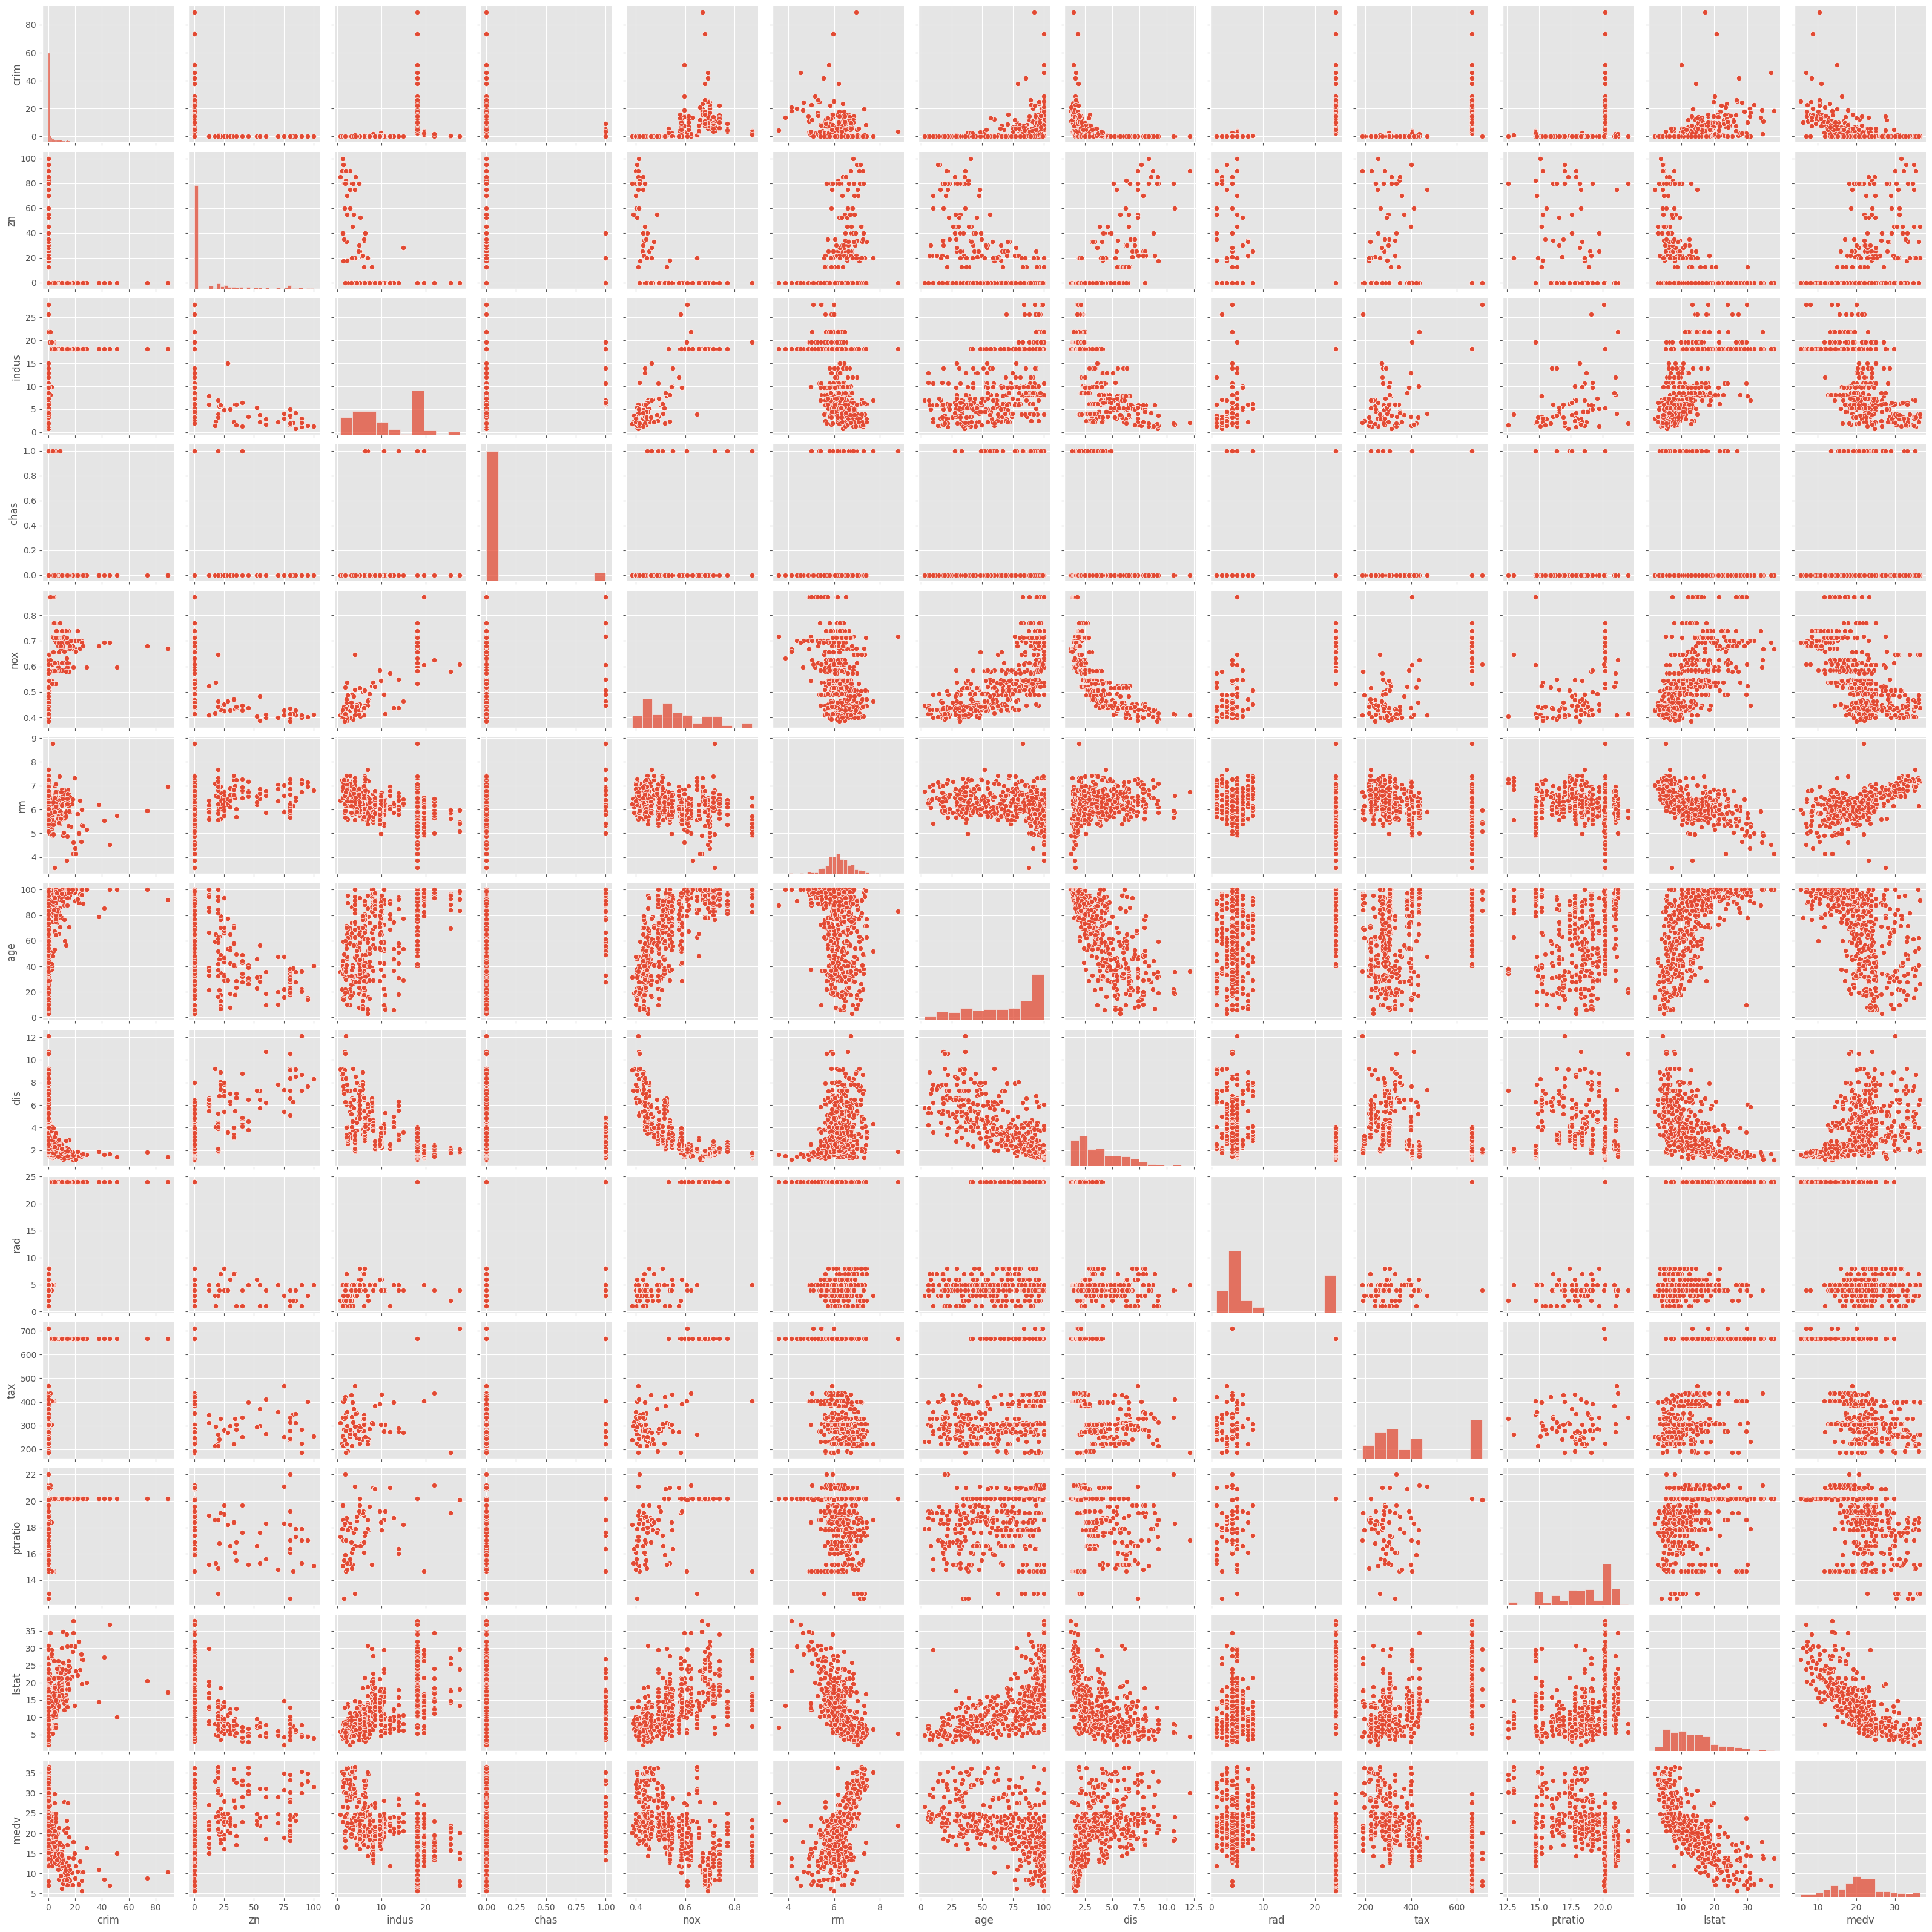

In [78]:
ipp.sns.pairplot(df_outlier_cleaned)

In [79]:
corr_mat=df_outlier_cleaned.corr()
corr_mat

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
crim,1.000000,-0.203706,0.410679,-0.065371,0.422928,-0.199504,0.357666,-0.390521,0.637234,0.592757,0.285594,0.453313,-0.482030
zn,-0.203706,1.000000,-0.536503,-0.055538,-0.513071,0.322274,-0.559513,0.685944,-0.306184,-0.302126,-0.376451,-0.425632,0.436177
indus,0.410679,-0.536503,1.000000,0.037869,0.766019,-0.369447,0.646233,-0.729908,0.588879,0.708080,0.366943,0.620535,-0.612220
chas,-0.065371,-0.055538,0.037869,1.000000,0.092005,0.060187,0.077140,-0.086312,-0.033668,-0.067897,-0.120863,-0.006830,0.097053
nox,0.422928,-0.513071,0.766019,0.092005,1.000000,-0.308291,0.727998,-0.771634,0.607829,0.665039,0.181092,0.606631,-0.569014
rm,-0.199504,0.322274,-0.369447,0.060187,-0.308291,1.000000,-0.271742,0.270629,-0.161677,-0.230787,-0.223777,-0.575358,0.568940
age,0.357666,-0.559513,0.646233,0.077140,0.727998,-0.271742,1.000000,-0.741121,0.452635,0.506743,0.272825,0.650283,-0.557098
dis,-0.390521,0.685944,-0.729908,-0.086312,-0.771634,0.270629,-0.741121,1.000000,-0.496763,-0.545198,-0.260617,-0.552922,0.439844
rad,0.637234,-0.306184,0.588879,-0.033668,0.607829,-0.161677,0.452635,-0.496763,1.000000,0.910061,0.450837,0.496024,-0.504338
tax,0.592757,-0.302126,0.708080,-0.067897,0.665039,-0.230787,0.506743,-0.545198,0.910061,1.000000,0.439957,0.546314,-0.590236


<class 'pandas.core.frame.DataFrame'>


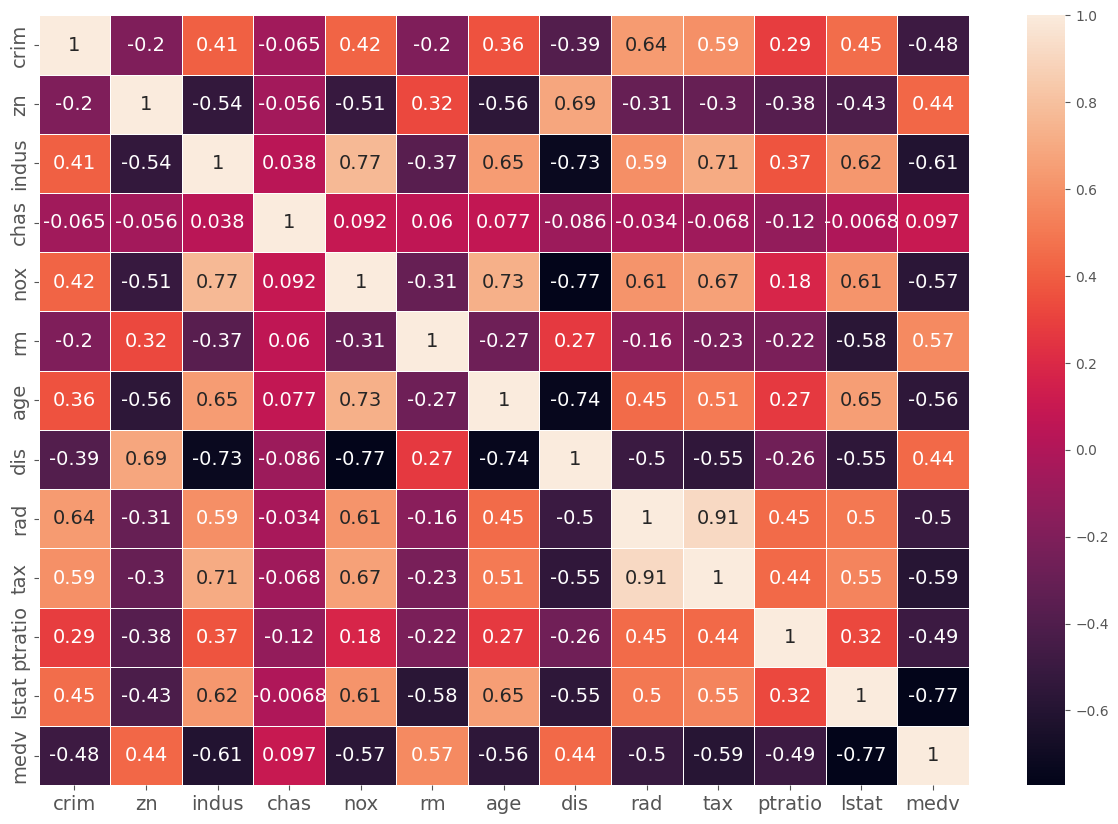

Plot done


In [80]:
print(type(corr_mat))
ipp.corrplot(corr_mat)

In [81]:
unique_counts = df.nunique()
print(unique_counts)
df_outlier_cleaned.info()

crim       504
zn          26
indus       76
chas         2
nox         81
rm         446
age        356
dis        412
rad          9
tax         66
ptratio     46
lstat      455
medv       229
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 466 entries, 1 to 506
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     466 non-null    float64
 1   zn       466 non-null    float64
 2   indus    466 non-null    float64
 3   chas     466 non-null    int64  
 4   nox      466 non-null    float64
 5   rm       466 non-null    float64
 6   age      466 non-null    float64
 7   dis      466 non-null    float64
 8   rad      466 non-null    int64  
 9   tax      466 non-null    int64  
 10  ptratio  466 non-null    float64
 11  lstat    466 non-null    float64
 12  medv     466 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 51.0 KB


## Adding the threshold from corr matrix for model

In [82]:
df_selected_3 = ipp.correlation_feature_selection(df_outlier_cleaned, lower_threshold=0.30, target_variable="medv")
ipp.interModel(df_selected_3, predictor_variable, "LTH_0.3")

In [83]:
df_selected_35 = ipp.correlation_feature_selection(df_outlier_cleaned, lower_threshold=0.35, target_variable="medv")
ipp.interModel(df_selected_35, predictor_variable, "LTH_0.35")

In [84]:
df_selected_4 = ipp.correlation_feature_selection(df_outlier_cleaned, lower_threshold=0.4, target_variable="medv")
ipp.interModel(df_selected_4, predictor_variable, "LTH_0.4")

In [85]:
skewness_values = df_selected_3.skew()

In [86]:
skewness_values

crim       5.268175
zn         2.293420
indus      0.271143
nox        0.734552
rm        -0.365107
age       -0.603338
dis        1.004178
tax        0.638410
ptratio   -0.867954
lstat      0.921894
medv       0.202563
dtype: float64

In [87]:
df_selected_3

,crim,zn,indus,nox,rm,age,dis,tax,ptratio,lstat,medv
1,0.00632,18.0,2.31,0.538,6.575,65.2,4.0900,296,15.3,4.98,24.0
2,0.02731,0.0,7.07,0.469,6.421,78.9,4.9671,242,17.8,9.14,21.6
3,0.02729,0.0,7.07,0.469,7.185,61.1,4.9671,242,17.8,4.03,34.7
4,0.03237,0.0,2.18,0.458,6.998,45.8,6.0622,222,18.7,2.94,33.4
5,0.06905,0.0,2.18,0.458,7.147,54.2,6.0622,222,18.7,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...
502,0.06263,0.0,11.93,0.573,6.593,69.1,2.4786,273,21.0,9.67,22.4
503,0.04527,0.0,11.93,0.573,6.120,76.7,2.2875,273,21.0,9.08,20.6
504,0.06076,0.0,11.93,0.573,6.976,91.0,2.1675,273,21.0,5.64,23.9
505,0.10959,0.0,11.93,0.573,6.794,89.3,2.3889,273,21.0,6.48,22.0


In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import boxcox
from sklearn.preprocessing import PowerTransformer

# Define skewness thresholds
high_skew_threshold = 1
moderate_skew_threshold = 0.5

# Calculate skewness for all columns
skew_values = df_selected_3.skew()

# Categorize columns based on skewness values
highly_skewed = skew_values[abs(skew_values) > high_skew_threshold].index.tolist()
moderately_skewed = skew_values[(abs(skew_values) >= moderate_skew_threshold) & (abs(skew_values) <= high_skew_threshold)].index.tolist()
low_skew = skew_values[abs(skew_values) < moderate_skew_threshold].index.tolist()

# Print categorized columns
print("Highly Skewed:", highly_skewed)
print("Moderately Skewed:", moderately_skewed)
print("Low Skew:", low_skew)

Highly Skewed: ['crim', 'zn', 'dis']
Moderately Skewed: ['nox', 'age', 'tax', 'ptratio', 'lstat']
Low Skew: ['indus', 'rm', 'medv']


In [89]:
import numpy as np
import pandas as pd
import scipy.stats as stats

# Function to check normality using multiple tests
def check_normality(df):
    results = []
    
    for col in df.columns:
        data = df[col].dropna()
        shapiro_p = stats.shapiro(data)[1] if len(data) < 5000 else np.nan  # Shapiro fails for large samples
        ks_p = stats.kstest(data, 'norm')[1]
        dagostino_p = stats.normaltest(data)[1]
        
        skewness = data.skew()
        
        results.append({
            "Feature": col,
            "Skewness": skewness,
            "Shapiro-Wilk p": shapiro_p,
            "K-S Test p": ks_p,
            "D’Agostino p": dagostino_p,
            "Needs Transformation": (abs(skewness) > 0.5) or (dagostino_p < 0.05) or (ks_p < 0.05)
        }) 
    
    return pd.DataFrame(results)

# Example usage
normality_results = check_normality(df)
print(normality_results)


    Feature  Skewness  Shapiro-Wilk p     K-S Test p   D’Agostino p  \
0      crim  5.223149    1.328552e-36  9.101765e-119  6.320632e-123   
1        zn  2.225666    7.882577e-34  1.687111e-117   2.702371e-50   
2     indus  0.295022    1.064229e-17   0.000000e+00   5.989300e-92   
3      chas  3.405904    2.350440e-40  1.687111e-117   1.815921e-80   
4       nox  0.729308    5.775830e-14  2.713323e-209   7.159367e-09   
5        rm  0.403612    2.410727e-10   0.000000e+00   5.902608e-09   
6       age -0.598963    2.230869e-18   0.000000e+00   1.619177e-25   
7       dis  1.011781    2.185128e-17   0.000000e+00   2.904509e-15   
8       rad  1.004815    8.072267e-30   0.000000e+00   4.034963e-26   
9       tax  0.669956    1.163013e-23   0.000000e+00   1.034519e-55   
10  ptratio -0.802325    2.358932e-17   0.000000e+00   1.054820e-10   
11    lstat  0.906460    8.285617e-14   0.000000e+00   3.780659e-13   
12     medv  1.108098    4.939735e-16   0.000000e+00   1.758319e-20   

    N

In [90]:
# df_selected_3.desc

In [91]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# from scipy.stats import boxcox
# from sklearn.preprocessing import PowerTransformer

# # Define skewness thresholds
# high_skew_threshold = 1
# moderate_skew_threshold = 0.5

# # Calculate skewness for all columns
# skew_values = df_selected_3.skew()

# # Categorize columns based on skewness values
# highly_skewed = skew_values[abs(skew_values) > high_skew_threshold].index.tolist()
# moderately_skewed = skew_values[(abs(skew_values) >= moderate_skew_threshold) & (abs(skew_values) <= high_skew_threshold)].index.tolist()
# low_skew = skew_values[abs(skew_values) < moderate_skew_threshold].index.tolist()

# # Print categorized columns
# print("Highly Skewed:", highly_skewed)
# print("Moderately Skewed:", moderately_skewed)
# print("Low Skew:", low_skew)

# # Store transformed data
# transformed_data = {}

# # Function to apply transformations and select the best one
# def transform_column(col, transformations):
#     original_skew = df_selected_3[col].skew()
#     best_method, best_data, best_skew = None, df_selected_3[col], original_skew

#     for name, transformed in transformations.items():
#         if transformed is not None:
#             new_skew = pd.Series(transformed).skew()
#             if abs(new_skew) < abs(best_skew) * 0.9:  # Accept if at least 10% better
#                 best_method, best_data, best_skew = name, transformed, new_skew
    
#     return best_method, best_data, best_skew

# # Apply transformations only to Highly and Moderately Skewed features
# best_skewness = {}




# # Apply transformations only to Highly and Moderately Skewed features
# for col in highly_skewed:
#     # Shift the data if it contains non-positive values
#     shift_val = abs(df_selected_3[col].min()) + 1 if (df_selected_3[col] <= 0).any() else 0

#     transformations = {
#         'log': np.log1p(df_selected_3[col] + shift_val) if (df_selected_3[col] + shift_val > 0).all() else None,
#         'sqrt': np.sqrt(df_selected_3[col] + shift_val) if (df_selected_3[col] + shift_val >= 0).all() else None,
#         'boxcox': boxcox(df_selected_3[col] + shift_val)[0] if (df_selected_3[col] + shift_val > 0).all() else None,
#         'power': PowerTransformer(method='yeo-johnson').fit_transform(df_selected_3[[col]]).flatten()
#     }

#     best_method, best_data, best_skew = transform_column(col, transformations)

#     if best_method:
#         # Rename the column with the transformation suffix
#         new_col_name = f"{col}_{best_method}"
#         df_selected_3[new_col_name] = best_data  # Add transformed column with the new name
#         df_selected_3.drop(columns=[col], inplace=True)  # Drop the original column
#     else:
#         # If no transformation, keep the original column
#         df_selected_3[col] = df_selected_3[col]

# # Print the updated dataframe with renamed columns
# print(df_selected_3.head())



In [92]:
# df

In [93]:
# df_selected_3

In [94]:
# df.skew()

In [95]:
# df_selected_3.skew()

In [96]:
# df_selected_3.head()

In [97]:
# ipp.sns.pairplot(df)

In [98]:
# ipp.sns.pairplot(df_selected_3)

In [99]:
# ipp.interModel(df_selected_3, "medv_power", "High_skewness")

In [100]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# from scipy.stats import boxcox, mstats
# from sklearn.preprocessing import PowerTransformer

# # Define skewness thresholds
# high_skew_threshold = 1
# moderate_skew_threshold = 0.5

# # Calculate skewness for all columns
# skew_values = df_selected_3.skew()

# # Categorize columns based on skewness values
# highly_skewed = skew_values[abs(skew_values) > high_skew_threshold].index.tolist()
# moderately_skewed = skew_values[(abs(skew_values) >= moderate_skew_threshold) & (abs(skew_values) <= high_skew_threshold)].index.tolist()
# low_skew = skew_values[abs(skew_values) < moderate_skew_threshold].index.tolist()

# # Store transformed data
# transformed_data = {}

# # Function to apply transformations and select the best one
# def transform_column(col, transformations):
#     original_skew = df_selected_3[col].skew()
#     best_method, best_data, best_skew = None, df_selected_3[col], original_skew

#     for name, transformed in transformations.items():
#         if transformed is not None:
#             new_skew = pd.Series(transformed).skew()
#             if abs(new_skew) < abs(best_skew) * 0.9:  # Accept if at least 10% better
#                 best_method, best_data, best_skew = name, transformed, new_skew
    
#     return best_method, best_data, best_skew

# # Apply transformations to Highly Skewed features
# for col in highly_skewed:
#     shift_val = abs(df_selected_3[col].min()) + 1 if (df_selected_3[col] <= 0).any() else 0

#     transformations = {
#         'log': np.log1p(df_selected_3[col] + shift_val) if (df_selected_3[col] + shift_val > 0).all() else None,
#         'sqrt': np.sqrt(df_selected_3[col] + shift_val) if (df_selected_3[col] + shift_val >= 0).all() else None,
#         'boxcox': boxcox(df_selected_3[col] + shift_val)[0] if (df_selected_3[col] + shift_val > 0).all() else None,
#         'power': PowerTransformer(method='yeo-johnson').fit_transform(df_selected_3[[col]]).flatten()
#     }

#     best_method, best_data, best_skew = transform_column(col, transformations)

#     if best_method:
#         new_col_name = f"{col}_{best_method}"
#         df_selected_3[new_col_name] = best_data  
#         df_selected_3.drop(columns=[col], inplace=True)  

# # Plot comparison for highly skewed features
# for col in highly_skewed:
#     transformed_col = [c for c in df_selected_3.columns if c.startswith(col + "_")]
#     if transformed_col:
#         transformed_col = transformed_col[0]
        
#         fig, axes = plt.subplots(1, 2, figsize=(12, 5))
#         sns.histplot(df_selected_3[transformed_col], bins=30, kde=True, ax=axes[0])
#         axes[0].set_title(f"Transformed Distribution: {transformed_col}")
        
#         sns.histplot(df_selected_3[transformed_col], bins=30, kde=True, ax=axes[1])
#         axes[1].set_title(f"Original Distribution: {col}")
        
#         plt.show()

# # Apply Winsorization to moderately skewed features
# for col in moderately_skewed:
#     original_data = df_selected_3[col].copy()
#     df_selected_3[col] = mstats.winsorize(df_selected_3[col], limits=[0.05, 0.05])  # Capping extreme 5% values

#     # Plot comparison
#     fig, axes = plt.subplots(1, 2, figsize=(12, 5))
#     sns.boxplot(x=original_data, ax=axes[0])
#     axes[0].set_title(f"Original Boxplot: {col}")
    
#     sns.boxplot(x=df_selected_3[col], ax=axes[1])
#     axes[1].set_title(f"Winsorized Boxplot: {col}")
    
#     plt.show()

# # Print updated DataFrame
# print(df_selected_3.head())


In [101]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


In [102]:

# # Print updated DataFrame
# print(df.head())

In [103]:

# Print updated DataFrame
# print(df_selected_3.head())
# df_selected_3.describe()

In [104]:
# df_selected_3.skew()

In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import boxcox, mstats
from sklearn.preprocessing import PowerTransformer

# Define skewness thresholds
high_skew_threshold = 1
moderate_skew_threshold = 0.5

# Calculate skewness for all columns
skew_values = df_selected_3.skew()

# Categorize columns based on skewness values
highly_skewed = skew_values[abs(skew_values) > high_skew_threshold].index.tolist()
moderately_skewed = skew_values[(abs(skew_values) >= moderate_skew_threshold) & (abs(skew_values) <= high_skew_threshold)].index.tolist()
low_skew = skew_values[abs(skew_values) < moderate_skew_threshold].index.tolist()

print("Highly Skewed Features:", highly_skewed)
print("Moderately Skewed Features:", moderately_skewed)



Highly Skewed Features: ['crim', 'zn', 'dis']
Moderately Skewed Features: ['nox', 'age', 'tax', 'ptratio', 'lstat']


## Working Part

In [106]:
# Function to handle highly skewed features
def handle_high_skew(df_selected_3, highly_skewed):
    print("\n🔹 Transforming Highly Skewed Features...")

    def transform_column(col, transformations):
        original_skew = df_selected_3[col].skew()
        best_method, best_data, best_skew = None, df_selected_3[col], original_skew

        for name, transformed in transformations.items():
            if transformed is not None:
                new_skew = pd.Series(transformed).skew()
                if abs(new_skew) < abs(best_skew) * 0.9:  # Accept if at least 10% better
                    best_method, best_data, best_skew = name, transformed, new_skew

        return best_method, best_data, best_skew

    for col in highly_skewed:
        original_data = df_selected_3[col].copy()  # Save original before dropping

        shift_val = abs(df_selected_3[col].min()) + 1 if (df_selected_3[col] <= 0).any() else 0

        transformations = {
            'log': np.log1p(df_selected_3[col] + shift_val) if (df_selected_3[col] + shift_val > 0).all() else None,
            'sqrt': np.sqrt(df_selected_3[col] + shift_val) if (df_selected_3[col] + shift_val >= 0).all() else None,
            'boxcox': None,
            'power': PowerTransformer(method='yeo-johnson').fit_transform(df_selected_3[[col]]).flatten()
        }

        try:
            if (df_selected_3[col] + shift_val > 0).all():
                transformations['boxcox'] = boxcox(df_selected_3[col] + shift_val)[0]
        except Exception as e:
            print(f"⚠️ Box-Cox failed for {col}: {e}")

        best_method, best_data, best_skew = transform_column(col, transformations)

        if best_method:
            new_col_name = f"{col}_{best_method}"
            df_selected_3[new_col_name] = best_data  
            df_selected_3.drop(columns=[col], inplace=True)

            # Plot comparison (Overlayed)
            plt.figure(figsize=(8, 5))
            sns.histplot(original_data, bins=30, kde=True, color="red", label="Original", alpha=0.5)
            sns.histplot(df_selected_3[new_col_name], bins=30, kde=True, color="blue", label="Transformed", alpha=0.5)
            plt.title(f"Overlayed Histogram: {col} (Original vs. {best_method})")
            plt.legend()
            plt.show()

    print("\n✅ Completed Transformations for Highly Skewed Features.")
    return df_selected_3


# Function to handle moderately skewed features
def handle_moderate_skew(df_selected_3, moderately_skewed):
    print("\n🔹 Applying Winsorization to Moderately Skewed Features...")

    for col in moderately_skewed:
        original_data = df_selected_3[col].copy()
        df_selected_3[col] = stats.mstats.winsorize(df_selected_3[col], limits=[0.05, 0.05])  # Capping extreme 5% values

        # Plot comparison (Before vs. After)
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        sns.boxplot(x=original_data, ax=axes[0], color="red")
        axes[0].set_title(f"Original Boxplot: {col}")

        sns.boxplot(x=df_selected_3[col], ax=axes[1], color="green")
        axes[1].set_title(f"Winsorized Boxplot: {col}")

        plt.show()

    print("\n✅ Completed Winsorization for Moderately Skewed Features.")
    return df_selected_3


# Main function to apply skew handling
def skew_handling(df_selected_3, highly_skewed, moderately_skewed):
    df_selected_3 = handle_high_skew(df_selected_3, highly_skewed)  # Handling high skew
    df_selected_3 = handle_moderate_skew(df_selected_3, moderately_skewed)  # Handling moderate skew
    
    print("\n✅ Skew Handling Completed. Returning Transformed DataFrame.")
    return df_selected_3


# Example Usage:
# df_selected_3 = skew_handling(df_selected_3, highly_skewed, moderately_skewed)



🔹 Transforming Highly Skewed Features...


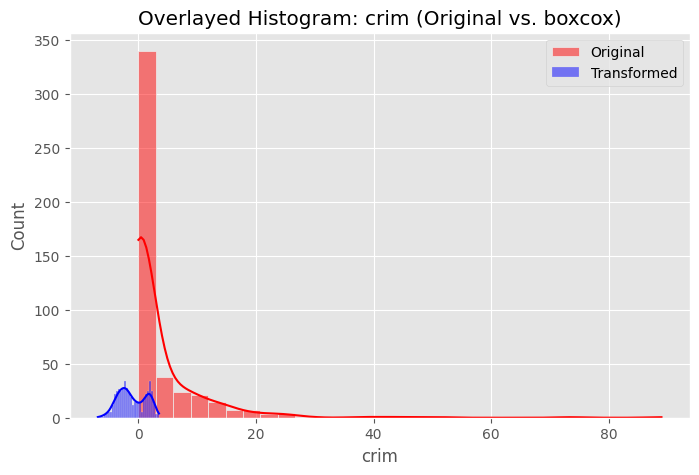

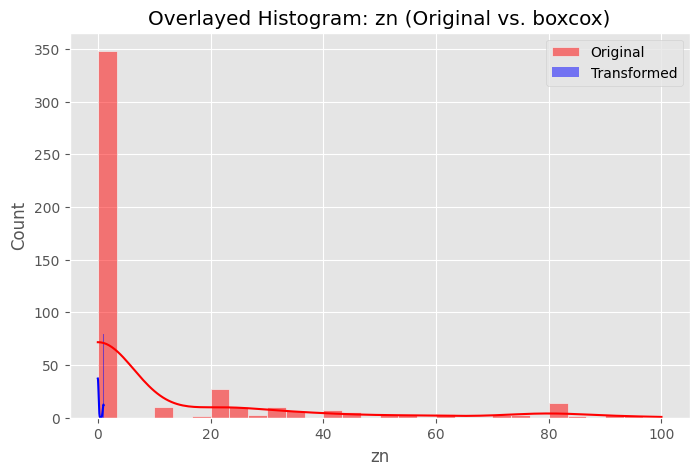

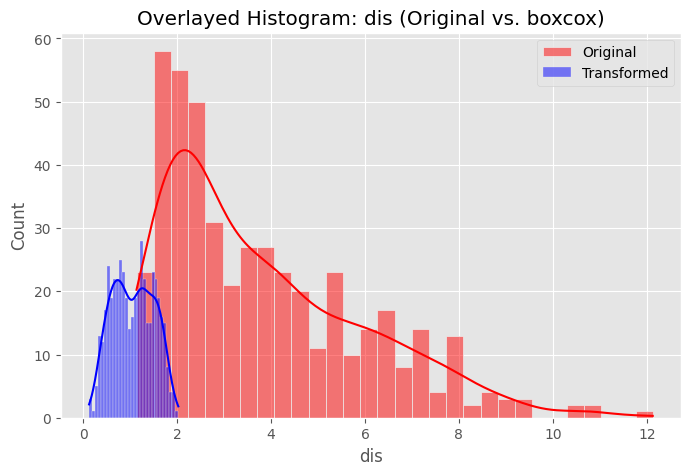


✅ Completed Transformations for Highly Skewed Features.

🔹 Applying Winsorization to Moderately Skewed Features...


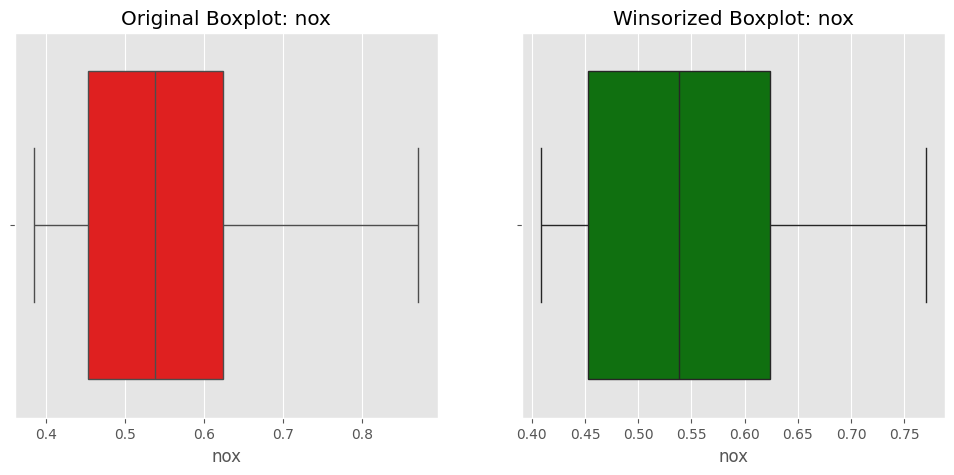

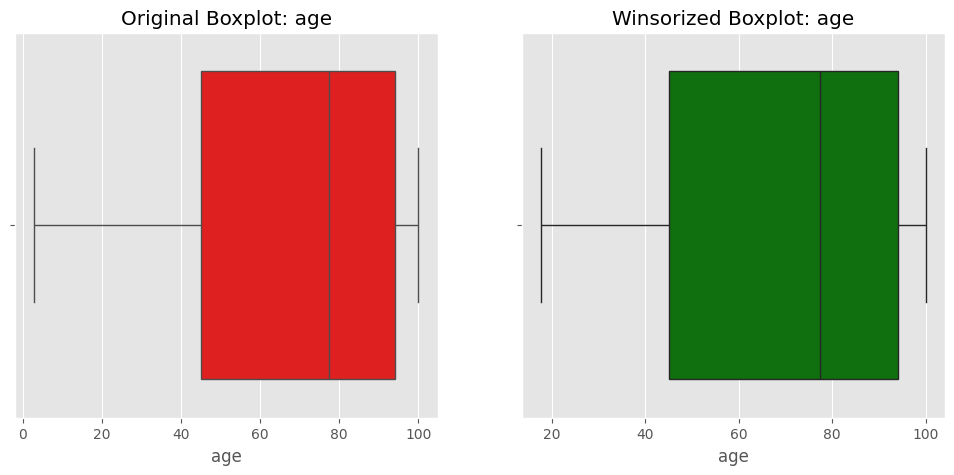

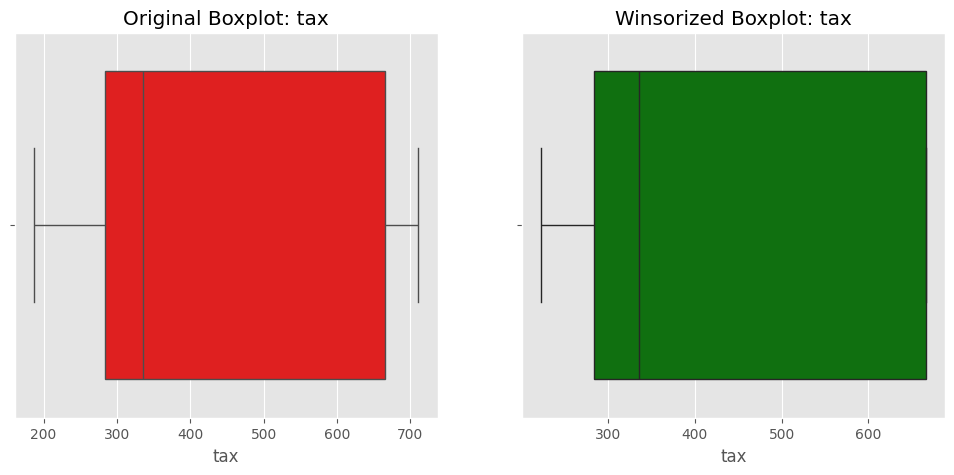

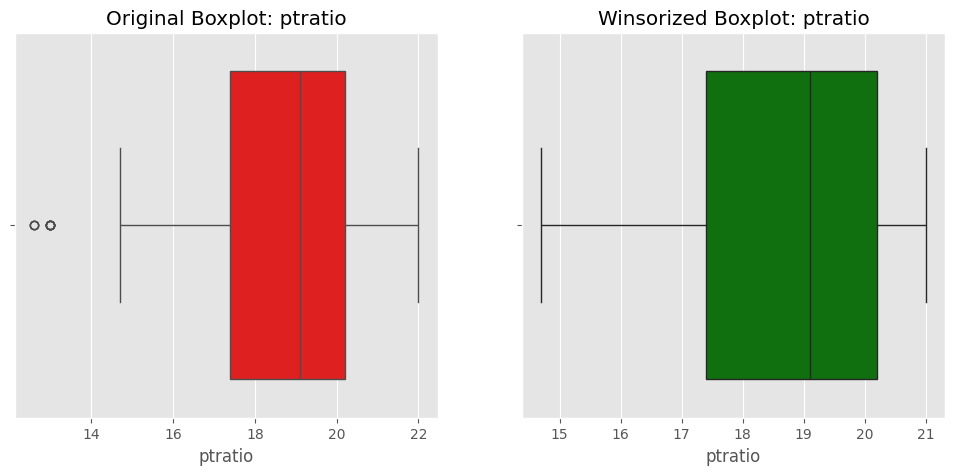

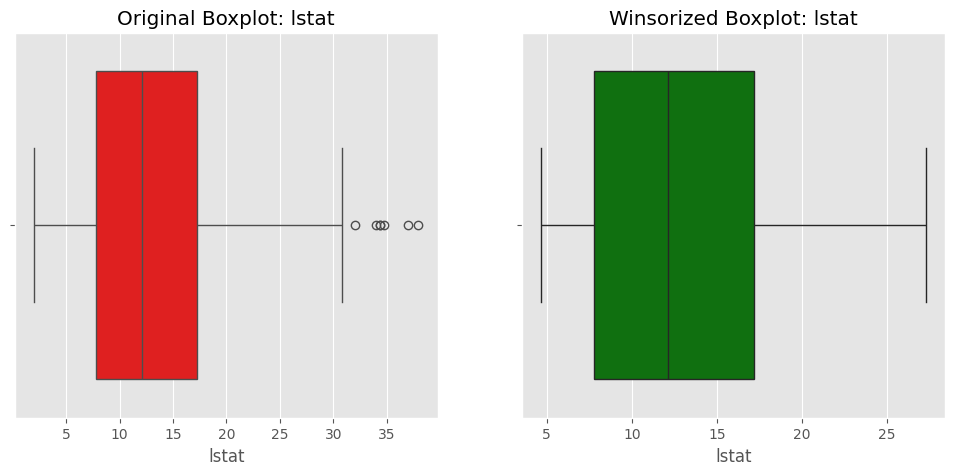


✅ Completed Winsorization for Moderately Skewed Features.

✅ Skew Handling Completed. Returning Transformed DataFrame.


In [107]:
df_selected_3 = skew_handling(df_selected_3, highly_skewed, moderately_skewed)

In [108]:
df_selected_3.head(2)

,indus,nox,rm,age,tax,ptratio,lstat,medv,crim_boxcox,zn_boxcox,dis_boxcox
1,2.31,0.538,6.575,65.2,296,15.3,4.98,24.0,-6.894364,0.969186,1.250040
2,7.07,0.469,6.421,78.9,242,17.8,9.14,21.6,-4.470496,0.000000,1.399778


In [110]:
ipp.interModel(df_selected_3, predictor_variable, "High n mid")

In [ ]:
# Rename the column if it contains the predictor_variable with a suffix (e.g., medv_power -> medv)
df_trimmed = df_selected_3.rename(columns={col: predictor_variable if predictor_variable in col else col 
                              for col in df_selected_3.columns})

# Print the modified DataFrame
print(df_trimmed)

     indus    nox     rm   age  tax  ptratio  lstat  medv  crim_boxcox  \
1     2.31  0.538  6.575  65.2  296     15.3   4.98  24.0    -6.894364   
2     7.07  0.469  6.421  78.9  242     17.8   9.14  21.6    -4.470496   
3     7.07  0.469  7.185  61.1  242     17.8   4.69  34.7    -4.471609   
4     2.18  0.458  6.998  45.8  223     18.7   4.69  33.4    -4.214769   
5     2.18  0.458  7.147  54.2  223     18.7   5.33  36.2    -3.134447   
..     ...    ...    ...   ...  ...      ...    ...   ...          ...   
502  11.93  0.573  6.593  69.1  273     21.0   9.67  22.4    -3.268327   
503  11.93  0.573  6.120  76.7  273     21.0   9.08  20.6    -3.724730   
504  11.93  0.573  6.976  91.0  273     21.0   5.64  23.9    -3.310223   
505  11.93  0.573  6.794  89.3  273     21.0   6.48  22.0    -2.520935   
506  11.93  0.573  6.030  80.8  273     21.0   7.88  11.9    -3.658731   

     zn_boxcox  dis_boxcox  
1     0.969186    1.250040  
2     0.000000    1.399778  
3     0.000000    1.3997

In [112]:
# df_selected_3.equals(df_trimmed)

In [113]:
# Define the predictor variable
# predictor_variable = "medv"

# Filter out the columns containing predictor_variable and predictor_variable_ in their names
columns_to_compare = [col for col in df_selected_3.columns if predictor_variable not in col]

# Subset the DataFrames to include only the columns we want to compare
df_selected_3_filtered = df_selected_3[columns_to_compare]
df_trimmed_filtered = df_trimmed[columns_to_compare]

# Compare the filtered DataFrames
are_identical = df_selected_3_filtered.equals(df_trimmed_filtered)

print("Are the DataFrames identical (excluding the predictor variable columns)?  ->  ", are_identical)


Are the DataFrames identical (excluding the predictor variable columns)?  ->   True


# Clean UP

In [121]:
clean = bool(int(input("Enter 1 for Yes, 0 for No: ")))  # Converts 1 to True and 0 to False
if clean:
    ipp.initial_Check()
else: print("  BYE  ")